# <b>[공모전] RNN 시계열 판매량 예측

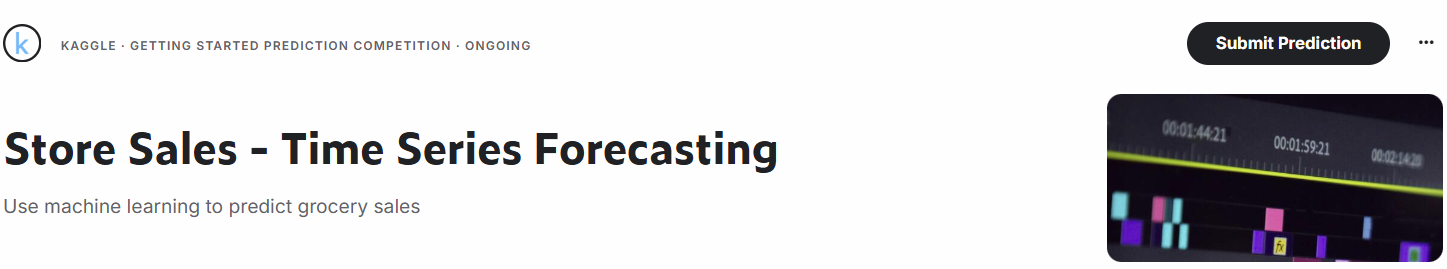
* https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, GRU, Bidirectional
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras.initializers import GlorotNormal    #Xavier

import math
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler


#----------------------------------------------------------------------------------  랜덤시드 고정 
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>평가 매트릭스

<pre>
<b>MSE : 모델학습 및 최적화</b>
<b>MSLogE : 모델평가 및 보고 </b>
    
<b>(R)MSE : 단순 수치 차이</b>
<b>(R)MSLogE : 비율(증강률)이 중요</b>

증감율에 대한 오차를 계산하고 싶은 경우
작은 수치의 오차에 민감하게 반응해야 하는 경우
성장률/비율이 중요한 경우 - 매출/재고 증강률, 환율, 금리(이자율)
음수값 계산 불가

 y       pred     mse        
100    110      10     ---   10%
1000  1010     10    ---     1%

| 지표 | 수식 (Formula) | 특징 및 용도 | 비고 |
| :--- | :---: | :--- | :--- |
| **MSE** | $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$ | 오차를 제곱하여 계산. 큰 오차에 매우 민감함. | 학습용 **Loss**로 주로 사용 |
| **RMSE** | $\sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}$ | MSE에 루트를 씌움. 실제 데이터와 단위가 일치함. | 일반적인 성능 **Metric** |
| **RMSLE** | $\sqrt{\frac{1}{n} \sum (\log(y_i+1) - \log(\hat{y}_i+1))^2}$ | 로그를 씌워 계산. 상대적 비율 오차를 측정함. | 아웃라이어가 많을 때 유리 |

# <b>Data Load

In [44]:
train = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\train.csv")
test = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\test.csv")
# holiday = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\holidays_events.csv")
# oil = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\oil.csv")
submit = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\sample_submission.csv")
# store = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\stores.csv")
# trans = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\transactions.csv")
dataset = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\train_merge20.csv", parse_dates=['date'])
# 공모전에선 이렇게 dataset처럼 데이터 잘라서 쓰면 안됌

In [28]:
#len(submit), len(test), len(train), len(dataset), len(submit)/3

(28512, 28512, 3000888, 1111440, 9504.0)

In [25]:
test.head(2)

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0


In [26]:
submit.head(2)

,id,sales
0,3000888,0.0
1,3000889,0.0


In [27]:
dataset.head(2)

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN


In [19]:
# train_store = pd.merge(train, store, how='outer', on = 'store_nbr')
# train_store.head(2)

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13


In [19]:
# train_store_trans = pd.merge(train_store, trans, how='outer', on = 'store_nbr')
# train_store_trans.head(2)

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13


# <b>train_test_split

<pre>
train: (1111440 - 9000) --> train(80%), val(20%)
test : 9000

In [30]:
test = dataset[-9000:]
len(dataset), len(test)

(1111440, 9000)

In [31]:
train, val = train_test_split(dataset[:-9000], test_size = 0.2, shuffle = False)
len(train), len(val)

(881952, 220488)

* 데이터 균형확인

<Axes: xlabel='store_nbr'>

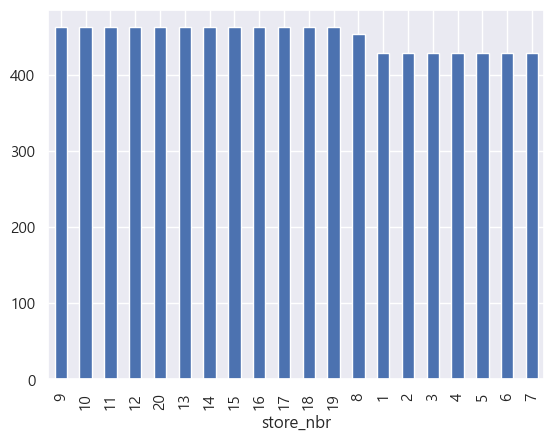

In [34]:
#train['store_nbr'].value_counts().plot(kind="bar") 
#test['store_nbr'].value_counts().plot(kind="bar")
#val['store_nbr'].value_counts().plot(kind="bar")

# <b>EDA

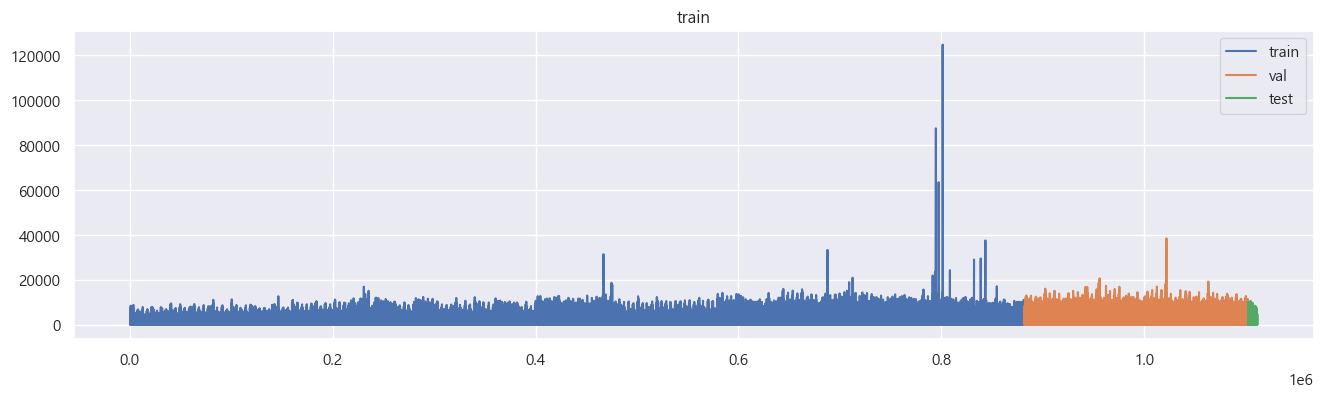

In [40]:
dataset['sales'][:len(train)].plot(figsize=(16,4),legend=True)  
dataset["sales"][len(train) :len(train)+len(val)].plot(figsize=(16,4),legend=True)  
dataset["sales"][len(train)+len(val) : ].plot(figsize=(16,4),legend=True)  

plt.legend(['train','val','test']) # 범례설정
plt.title('train')
plt.show()

0.8에서 많이 튐 -> 이상치 확인 필요
블프아님

# <b>전처리 & 가공

transactions(판매건수)에서 결측보임 <br>
id : drop<br>
family, city, state, type : object<br>
상위 top파생피쳐 20개<br>
seasonal패턴 : sin,cos사이클

In [45]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1111440 entries, 0 to 1111439
Data columns (total 11 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   id            1111440 non-null  int64         
 1   date          1111440 non-null  datetime64[ns]
 2   store_nbr     1111440 non-null  int64         
 3   family        1111440 non-null  object        
 4   sales         1111440 non-null  float64       
 5   onpromotion   1111440 non-null  int64         
 6   city          1111440 non-null  object        
 7   state         1111440 non-null  object        
 8   type          1111440 non-null  object        
 9   cluster       1111440 non-null  int64         
 10  transactions  1073952 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 93.3+ MB


## <b>파생피쳐
* 상위 top파생피쳐 20개

In [ ]:
dataset['month'] = dataset['date'].dt.month
dataset['day'] = dataset['date'].dt.day
dataset['week'] = dataset['date'].dt.weekday #월 = 0 ~ 일 = 6 , 주말 = week >=5
#dataset['weekofyear'] = dataset['date'].dt.year
dataset['is_weekend'] = dataset[dataset['week']>=5].astype(int) 

dataset['week_sin'] = np.sin(2*np.pi * dataset['week']/7)
dataset['week_cos'] = np.cos(2*np.pi * dataset['week']/7)
dataset['month_sin'] = np.sin(2*np.pi * dataset['week']/12)
dataset['month_sin'] = np.cos(2*np.pi * dataset['week']/12)


dataset['lag_7'] = 
dataset['lag_14'] = 
dataset['lag_28'] = 
dataset['rolling_mean_7'] = 
dataset['rolling_mean_14'] = 
dataset['rolling_std_7'] = 
dataset['promotion_ratio'] = 
dataset['store_sales_mean'] = 
dataset['family_sales_mean'] = 
dataset['store_family_mean'] = 
dataset['cluster_mean'] = 
dataset['transactions_lag'] = 
dataset['holiday'] = 

## <b>스케일링

## <b>윈도우 슬라이딩

## <font color=red><b>input_shape : 3D
* samples : 데이터 갯수
* timestep : window_size
* features : 변수갯수 == df['cnt']

# <b>모델 & 평가

# <b>답안지 제출